<a href="https://colab.research.google.com/github/Priya-git2005/Gen-AI_CTTC/blob/main/Gen_AI_(Day3_4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

In [2]:
from keras.datasets import mnist
(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [4]:
for i in range(0,10):
  print(i,len(x_train[y_train==i]))

0 5923
1 6742
2 5958
3 6131
4 5842
5 5421
6 5918
7 6265
8 5851
9 5949


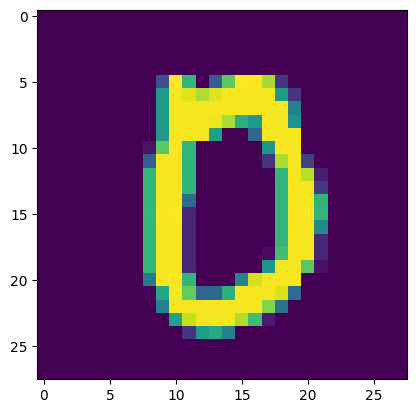

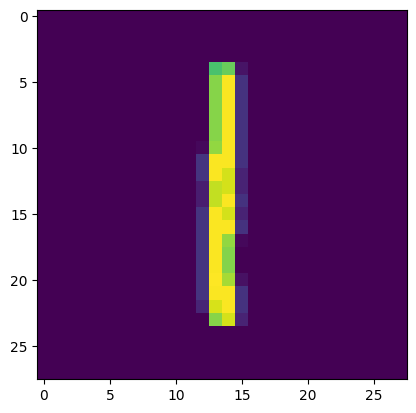

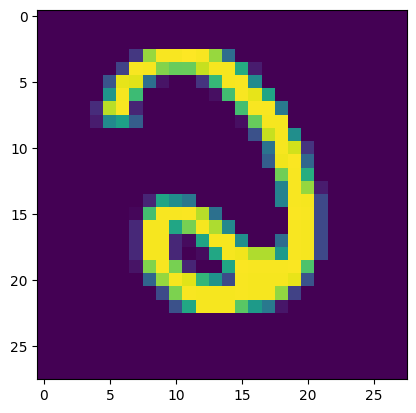

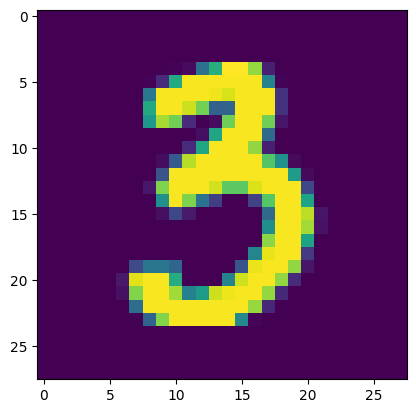

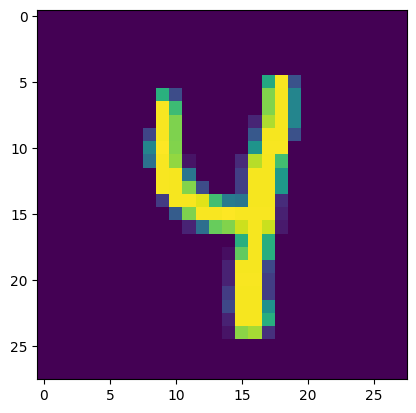

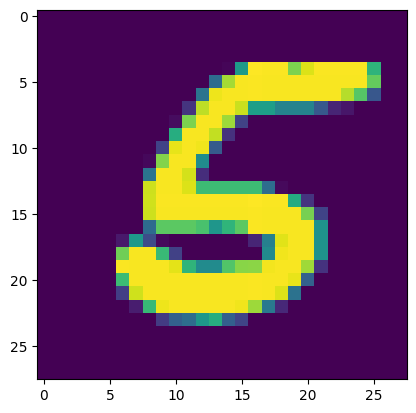

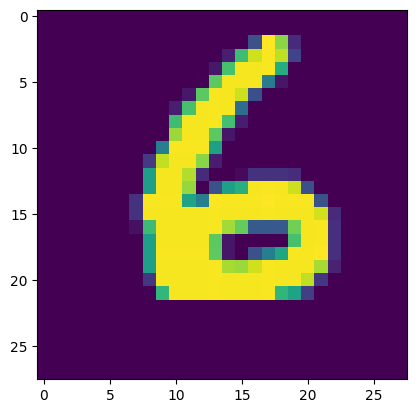

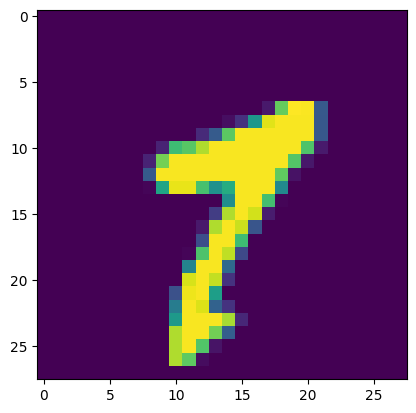

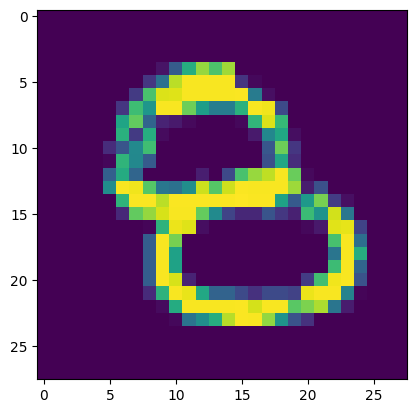

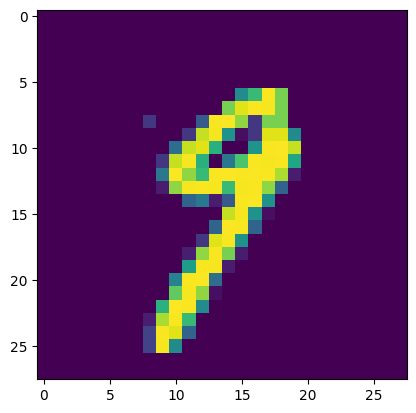

In [5]:
for i in range(0,10):
  plt.imshow(x_train[y_train==i][np.random.randint(0,4000)])
  plt.show()

In [6]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [7]:
from keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [8]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000, 10)
(10000, 28, 28)
(10000, 10)


In [9]:
#reshape
x_train = x_train.reshape(60000,28,28,1)
x_test = x_test.reshape(10000,28,28,1)

In [10]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000, 10)
(10000, 28, 28, 1)
(10000, 10)


In [11]:
#normalize
x_train= x_train/255
x_test = x_test/255

In [12]:
#depp cnn model
#modules
from keras.layers import Conv2D,MaxPooling2D,Flatten
#model
model = Sequential()
#conv or input
model.add(Conv2D(30,(5,5),input_shape=(28,28,1),activation='relu'))
#pool
model.add(MaxPooling2D(2,2))

#conv or input
model.add(Conv2D(15,(3,3),activation='relu'))
#pool
model.add(MaxPooling2D(2,2))
#flatten
model.add(Flatten())
#fully conn
#hiddin
model.add(Dense(200,activation='relu'))
model.add(Dense(100,activation='relu'))
#out
model.add(Dense(10,activation='softmax'))
#model.compile
model.compile(Adam(learning_rate=0.01),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.fit(x_train,y_train,validation_split=0.2,epochs=10)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9276 - loss: 0.2385 - val_accuracy: 0.9241 - val_loss: 0.2687
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9587 - loss: 0.1485 - val_accuracy: 0.9540 - val_loss: 0.1726
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9623 - loss: 0.1398 - val_accuracy: 0.9690 - val_loss: 0.1101
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9671 - loss: 0.1228 - val_accuracy: 0.9694 - val_loss: 0.1255
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9695 - loss: 0.1169 - val_accuracy: 0.9750 - val_loss: 0.0966
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9697 - loss: 0.1148 - val_accuracy: 0.9655 - val_loss: 0.1324
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9705 - loss: 0.1202 - val_accuracy: 0.9744 - val_loss: 0.1031
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9741 - loss: 0.1029 

In [14]:
#testing
from google.colab import files
a = files.upload()

Saving WhatsApp Image 2026-08-07 at 10.38.59 AM.jpeg to WhatsApp Image 2026-08-07 at 10.38.59 AM.jpeg


In [15]:
b = list(a.keys())[0]
print(b)

WhatsApp Image 2026-08-07 at 10.38.59 AM.jpeg


In [16]:
c = np.fromstring(a[b],np.uint8)
print(c) #array convert

[255 216 255 ... 127 255 217]


/tmp/ipykernel_3754/3113946334.py:1: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  c = np.fromstring(a[b],np.uint8)


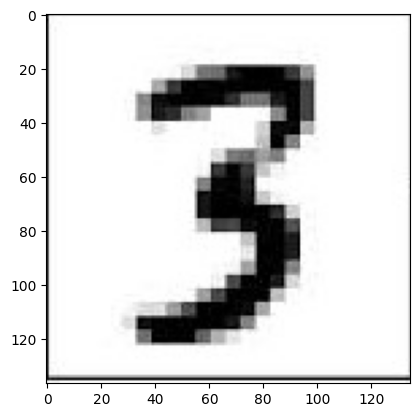

In [19]:
import cv2
img =cv2.imdecode(c,cv2.IMREAD_COLOR)
plt.imshow(img,cmap='gray')

In [20]:
img.shape

(137, 135, 3)

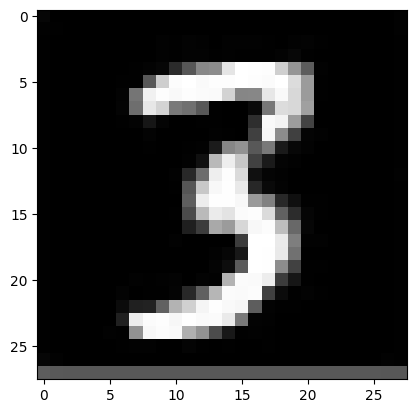

In [22]:
img = cv2.resize(img,(28,28))
img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY) #conv -> grayscale
img = cv2.bitwise_not(img) #invert
plt.imshow(img,cmap='gray')

In [23]:
img.shape

(28, 28)

In [24]:
#color code add
img = img / 255
img = img.reshape(1,28,28,1)

In [25]:
#predict
p = model.predict(img)
p

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step


array([[1.14074188e-24, 3.00681217e-36, 7.23302874e-13, 1.00000000e+00,
        2.50832425e-42, 1.40102235e-11, 0.00000000e+00, 2.56422423e-19,
        3.85061124e-12, 1.25345924e-21]], dtype=float32)